In [1]:
# ---- Configuration (edit these) ----
from pathlib import Path

# Input files
AURORA_PREDICTION_FILE = "/mnt/data2/cams/aurora-cams-predictions_2025-01-11_2025-01-16.nc"
CAMS_FORECAST_FILE = "/mnt/data2/cams/2025-01-11T00Z-cams-forecast-atmospheric.nc"

# Variable selection. Keep these equal if both files use the same name.
AURORA_VAR_NAME = "no2"
CAMS_VAR_NAME = "no2"

# Display labels (can differ from variable names)
AURORA_PLOT_LABEL = AURORA_VAR_NAME
CAMS_PLOT_LABEL = CAMS_VAR_NAME
COLORBAR_LABEL = "NO$_2$ MMR"  # None -> auto label with unit(s)

# For 3D variables with pressure_level (set None for surface variables).
PRESSURE_LEVEL_HPA = 1000

# Time filtering/alignment
TIME_STEP_HOURS = 12  # Keep every N hours before matching
INIT_DATETIME_UTC = None  # Example: "2026-02-01T00:00:00"; used only if CAMS lacks absolute time

# Plot layout and style
MAX_COLUMNS = 5
FIGSIZE_PER_PANEL = (3.6, 3.0)
COLOR_PERCENTILES = (1, 99)  # common color scale across both datasets
COLORMAP = "jet"

# Spatial boundary: tuples in degrees as (min, max). Use None for full domain.
LATITUDE_BOUNDARY = (30.0, 40.0)  # Example: (20.0, 55.0)
LONGITUDE_BOUNDARY = (-125.0, -115.0)  # Example: (-130.0, -60.0)


# GIF output
GENERATE_GIFS = True
GIF_NUM_STEPS = 10
GIF_FRAME_DURATION_MS = 700
AURORA_GIF_OUTPUT = f"/mnt/data2/aurora/examples/aurora_{AURORA_VAR_NAME}_{PRESSURE_LEVEL_HPA}hpa_10plots.gif"
CAMS_GIF_OUTPUT = f"/mnt/data2/aurora/examples/cams_{AURORA_VAR_NAME}_{PRESSURE_LEVEL_HPA}hpa_10plots.gif"
# Cartopy background
LAND_FACE_COLOR = "#f0efe8"
COASTLINE_LINEWIDTH = 0.5
SHOW_COUNTRY_BOUNDARIES = False
SHOW_STATE_BOUNDARIES = False
BOUNDARY_LINE_COLOR = "#4a4a4a"
COUNTRY_BOUNDARY_LINEWIDTH = 0.45
STATE_BOUNDARY_LINEWIDTH = 0.35


# Compare Aurora Prediction vs CAMS Forecast Maps

This notebook aligns two NetCDF files by time and plots the selected variable for the full prediction range with a common colorbar.


In [2]:
from io import BytesIO
import math

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from PIL import Image


def _to_datetime64s(values):
    return np.array(values).astype("datetime64[s]")


def _ensure_time_dim(ds, init_datetime_utc=None):
    if "time" in ds.dims:
        ds = ds.assign_coords(time=_to_datetime64s(ds["time"].values))
        return ds

    if "valid_time" in ds:
        vt = _to_datetime64s(ds["valid_time"].values)
        if "forecast_period" in ds.dims:
            ds = ds.assign_coords(time=("forecast_period", vt.reshape(-1)))
            ds = ds.swap_dims({"forecast_period": "time"})
            return ds
        if "time" in ds.dims:
            ds = ds.assign_coords(time=vt.reshape(-1))
            return ds

    if "forecast_period" in ds.dims:
        if init_datetime_utc is None:
            if "forecast_reference_time" in ds:
                t0 = np.datetime64(ds["forecast_reference_time"].values)
            else:
                raise ValueError(
                    "Dataset has forecast_period but no absolute time. Set INIT_DATETIME_UTC in config."
                )
        else:
            t0 = np.datetime64(init_datetime_utc)

        fp = ds["forecast_period"].values.astype("timedelta64[s]")
        ds = ds.assign_coords(time=("forecast_period", _to_datetime64s(t0 + fp)))
        ds = ds.swap_dims({"forecast_period": "time"})
        return ds

    raise ValueError("Could not infer a usable time dimension for dataset.")


def _sel_pressure_level(da, target_hpa):
    if target_hpa is None:
        return da, None
    if "pressure_level" not in da.dims:
        raise ValueError("PRESSURE_LEVEL_HPA was set, but variable has no pressure_level dimension.")

    levels = da["pressure_level"].values.astype(int)
    if target_hpa in set(levels.tolist()):
        level = int(target_hpa)
    else:
        level = int(levels[np.argmin(np.abs(levels - int(target_hpa)))])
        print(f"Requested {target_hpa} hPa not found; using nearest level {level} hPa.")
    return da.sel(pressure_level=level), level


def _keep_time_cadence(da, step_hours):
    t = _to_datetime64s(da.time.values)
    t0 = t.min()
    delta_h = ((t - t0) / np.timedelta64(1, "h")).astype(int)
    mask = (delta_h % int(step_hours)) == 0
    return da.isel(time=np.where(mask)[0])


def _normalize_bounds(bounds, name):
    if bounds is None:
        return None
    if len(bounds) != 2:
        raise ValueError(f"{name} must be a 2-value tuple/list as (min, max).")
    lo, hi = float(bounds[0]), float(bounds[1])
    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError(f"{name} values must be finite numbers.")
    return (lo, hi) if lo <= hi else (hi, lo)


def _is_longitude_360(coord_values):
    coord_values = np.asarray(coord_values, dtype=float)
    return float(np.nanmin(coord_values)) >= 0.0 and float(np.nanmax(coord_values)) > 180.0


def _convert_longitude_to_coord_system(lon, coord_values):
    lon = float(lon)
    if _is_longitude_360(coord_values):
        return lon % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def _coord_slice_from_bounds(coord_values, bounds, name, *, convert_longitude=False):
    norm = _normalize_bounds(bounds, name)
    if norm is None:
        return None
    lo, hi = norm

    if convert_longitude:
        lo = _convert_longitude_to_coord_system(lo, coord_values)
        hi = _convert_longitude_to_coord_system(hi, coord_values)
        if lo > hi:
            raise ValueError(
                f"{name} crosses the dateline after conversion for this dataset. "
                "Please provide a non-wrapping boundary for now."
            )

    return slice(lo, hi) if coord_values[0] <= coord_values[-1] else slice(hi, lo)


def _apply_latlon_boundary(da, latitude_boundary=None, longitude_boundary=None):
    if "latitude" not in da.dims or "longitude" not in da.dims:
        raise ValueError(f"Expected latitude/longitude dimensions, got {da.dims}.")

    lat_slice = _coord_slice_from_bounds(da.latitude.values, latitude_boundary, "LATITUDE_BOUNDARY")
    lon_slice = _coord_slice_from_bounds(
        da.longitude.values,
        longitude_boundary,
        "LONGITUDE_BOUNDARY",
        convert_longitude=True,
    )

    if lat_slice is not None:
        da = da.sel(latitude=lat_slice)
    if lon_slice is not None:
        da = da.sel(longitude=lon_slice)

    if da.sizes.get("latitude", 0) == 0 or da.sizes.get("longitude", 0) == 0:
        raise ValueError(
            "Latitude/longitude boundary produced an empty selection. "
            "Check boundary values and longitude convention (-180..180 vs 0..360)."
        )
    return da


def _extent_from_bounds_or_data(da, latitude_boundary=None, longitude_boundary=None):
    lat_bounds = _normalize_bounds(latitude_boundary, "LATITUDE_BOUNDARY")
    lon_bounds = _normalize_bounds(longitude_boundary, "LONGITUDE_BOUNDARY")

    if lat_bounds is None:
        lat_bounds = (float(np.nanmin(da.latitude.values)), float(np.nanmax(da.latitude.values)))

    if lon_bounds is None:
        lon_bounds = (float(np.nanmin(da.longitude.values)), float(np.nanmax(da.longitude.values)))
    else:
        lo = _convert_longitude_to_coord_system(lon_bounds[0], da.longitude.values)
        hi = _convert_longitude_to_coord_system(lon_bounds[1], da.longitude.values)
        lon_bounds = (lo, hi) if lo <= hi else (hi, lo)

    return [lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]]


def _to_2d_latlon_field(da_slice):
    field_da = da_slice.squeeze(drop=True)
    if field_da.ndim != 2:
        # Keep only latitude/longitude slices; all other dims should be singleton by now.
        extra_dims = [d for d in field_da.dims if d not in {"latitude", "longitude"}]
        if extra_dims:
            indexers = {d: 0 for d in extra_dims if field_da.sizes.get(d, 1) == 1}
            field_da = field_da.isel(indexers).squeeze(drop=True)

    if field_da.ndim != 2:
        raise ValueError(
            f"Expected a 2D lat/lon field after selecting time; got dims={field_da.dims}, shape={field_da.shape}."
        )

    if "latitude" not in field_da.dims or "longitude" not in field_da.dims:
        raise ValueError(f"Expected latitude/longitude dimensions, got {field_da.dims}.")

    if field_da.dims != ("latitude", "longitude"):
        field_da = field_da.transpose("latitude", "longitude")

    return field_da


def _label_with_unit(label, unit):
    if unit is None or str(unit).strip() == "":
        return label
    return f"{label} [{unit}]"


def _scalar_label(aurora_da, cams_da, aurora_label, cams_label, colorbar_label=None):
    aurora_units = aurora_da.attrs.get("units")
    cams_units = cams_da.attrs.get("units")

    if colorbar_label is None:
        base_label = aurora_label if aurora_label == cams_label else f"{aurora_label} / {cams_label}"
    else:
        base_label = colorbar_label

    if aurora_units and cams_units and aurora_units != cams_units:
        units_text = f"{aurora_units} / {cams_units}"
    else:
        units_text = aurora_units or cams_units

    return _label_with_unit(base_label, units_text)


def _add_map_context(ax):
    ax.add_feature(cfeature.LAND, facecolor=LAND_FACE_COLOR, zorder=0)
    ax.coastlines(linewidth=COASTLINE_LINEWIDTH)

    if SHOW_COUNTRY_BOUNDARIES:
        ax.add_feature(
            cfeature.BORDERS,
            edgecolor=BOUNDARY_LINE_COLOR,
            linewidth=COUNTRY_BOUNDARY_LINEWIDTH,
        )

    if SHOW_STATE_BOUNDARIES:
        ax.add_feature(
            cfeature.STATES,
            edgecolor=BOUNDARY_LINE_COLOR,
            linewidth=STATE_BOUNDARY_LINEWIDTH,
        )


def _plot_map_pairs_by_time(
    aurora_da,
    cams_da,
    title_prefix,
    vmin,
    vmax,
    cmap,
    aurora_label="Aurora",
    cams_label="CAMS",
    colorbar_label=None,
    latitude_boundary=None,
    longitude_boundary=None,
):
    aurora_times = _to_datetime64s(aurora_da.time.values)
    cams_times = _to_datetime64s(cams_da.time.values)
    if len(aurora_times) != len(cams_times) or not np.array_equal(aurora_times, cams_times):
        raise ValueError("Aurora and CAMS times must be aligned before plotting pairs.")

    nrows = len(aurora_times)
    if nrows == 0:
        raise ValueError("No timesteps to plot.")

    fig = plt.figure(figsize=(FIGSIZE_PER_PANEL[0] * 2, FIGSIZE_PER_PANEL[1] * nrows + 0.8))
    gs = fig.add_gridspec(
        nrows + 1,
        2,
        height_ratios=([1] * nrows) + [0.04],
        hspace=0.24,
        wspace=0.08,
    )

    axs = np.empty((nrows, 2), dtype=object)
    for i in range(nrows):
        axs[i, 0] = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        axs[i, 1] = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())

    cbar_ax = fig.add_subplot(gs[nrows, :])

    aurora_lon2d, aurora_lat2d = np.meshgrid(aurora_da.longitude.values, aurora_da.latitude.values)
    cams_lon2d, cams_lat2d = np.meshgrid(cams_da.longitude.values, cams_da.latitude.values)
    aurora_extent = _extent_from_bounds_or_data(
        aurora_da, latitude_boundary=latitude_boundary, longitude_boundary=longitude_boundary
    )
    cams_extent = _extent_from_bounds_or_data(
        cams_da, latitude_boundary=latitude_boundary, longitude_boundary=longitude_boundary
    )

    mappable = None
    for i, t in enumerate(aurora_times):
        aurora_field = _to_2d_latlon_field(aurora_da.isel(time=i))
        cams_field = _to_2d_latlon_field(cams_da.isel(time=i))

        pairs = [
            (
                axs[i, 0],
                aurora_lon2d,
                aurora_lat2d,
                aurora_field.values,
                f"Aurora ({aurora_label}) | {t}",
                aurora_extent,
            ),
            (
                axs[i, 1],
                cams_lon2d,
                cams_lat2d,
                cams_field.values,
                f"CAMS ({cams_label}) | {t}",
                cams_extent,
            ),
        ]

        for ax, lon2d, lat2d, field, panel_title, extent in pairs:
            mappable = ax.pcolormesh(
                lon2d,
                lat2d,
                field,
                transform=ccrs.PlateCarree(),
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
            _add_map_context(ax)
            ax.set_extent(extent, crs=ccrs.PlateCarree())
            ax.set_title(panel_title, fontsize=9)

    scalar_label = _scalar_label(aurora_da, cams_da, aurora_label, cams_label, colorbar_label)
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(scalar_label)
    cbar.ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    cbar.ax.tick_params(axis="x", labelsize=8, length=2, width=0.7, pad=1)

    fig.suptitle(title_prefix)
    fig.subplots_adjust(top=0.965, bottom=0.08, left=0.05, right=0.98)


def _plot_global_boxplots_by_time(
    aurora_da,
    cams_da,
    title_prefix,
    aurora_label="Aurora",
    cams_label="CAMS",
    colorbar_label=None,
):
    aurora_times = _to_datetime64s(aurora_da.time.values)
    cams_times = _to_datetime64s(cams_da.time.values)
    if len(aurora_times) != len(cams_times) or not np.array_equal(aurora_times, cams_times):
        raise ValueError("Aurora and CAMS times must be aligned before plotting boxplots.")

    n = len(aurora_times)
    if n == 0:
        raise ValueError("No timesteps to plot.")

    aurora_samples = []
    cams_samples = []
    for i in range(n):
        aurora_vals = _to_2d_latlon_field(aurora_da.isel(time=i)).values.ravel()
        cams_vals = _to_2d_latlon_field(cams_da.isel(time=i)).values.ravel()
        aurora_samples.append(aurora_vals[np.isfinite(aurora_vals)])
        cams_samples.append(cams_vals[np.isfinite(cams_vals)])

    fig_width = max(10.0, 1.0 * n)
    fig, ax = plt.subplots(figsize=(fig_width, 4.0))

    centers = np.arange(n)
    offset = 0.18
    width = 0.32

    aurora_bp = ax.boxplot(
        aurora_samples,
        positions=centers - offset,
        widths=width,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95),
    )
    cams_bp = ax.boxplot(
        cams_samples,
        positions=centers + offset,
        widths=width,
        patch_artist=True,
        showfliers=False,
        whis=(5, 95),
    )

    for box in aurora_bp["boxes"]:
        box.set(facecolor="#1f77b4", alpha=0.45)
    for box in cams_bp["boxes"]:
        box.set(facecolor="#ff7f0e", alpha=0.45)

    labels = [np.datetime_as_string(t, unit="h") for t in aurora_times]
    ax.set_xticks(centers)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlim(-0.6, n - 0.4)
    ax.grid(axis="y", linewidth=0.5, alpha=0.4)

    scalar_label = _scalar_label(aurora_da, cams_da, aurora_label, cams_label, colorbar_label)
    ax.set_ylabel(scalar_label)
    ax.set_title(title_prefix)

    legend_handles = [
        plt.Line2D([0], [0], color="#1f77b4", lw=8, alpha=0.45),
        plt.Line2D([0], [0], color="#ff7f0e", lw=8, alpha=0.45),
    ]
    ax.legend(legend_handles, [f"Aurora ({aurora_label})", f"CAMS ({cams_label})"], loc="upper right")

    fig.tight_layout()

def _save_map_gif_by_time(
    da,
    output_path,
    title_prefix,
    vmin,
    vmax,
    cmap,
    series_label,
    colorbar_label=None,
    frame_duration_ms=700,
    latitude_boundary=None,
    longitude_boundary=None,
):
    times = _to_datetime64s(da.time.values)
    if len(times) == 0:
        raise ValueError("No timesteps to render for GIF.")

    lon2d, lat2d = np.meshgrid(da.longitude.values, da.latitude.values)
    extent = _extent_from_bounds_or_data(
        da, latitude_boundary=latitude_boundary, longitude_boundary=longitude_boundary
    )
    scalar_label = _scalar_label(da, da, series_label, series_label, colorbar_label)
    frames = []

    for i, t in enumerate(times):
        field = _to_2d_latlon_field(da.isel(time=i)).values
        fig, ax = plt.subplots(
            figsize=(max(6.0, FIGSIZE_PER_PANEL[0] * 1.8), max(3.6, FIGSIZE_PER_PANEL[1] * 1.5)),
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
        mappable = ax.pcolormesh(
            lon2d,
            lat2d,
            field,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        _add_map_context(ax)
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.set_title(f"{title_prefix} | {np.datetime_as_string(t, unit='h')}")

        cbar = fig.colorbar(mappable, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
        cbar.set_label(scalar_label)
        fig.tight_layout()

        buf = BytesIO()
        fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).convert("P", palette=Image.ADAPTIVE))

    output_path = Path(output_path).expanduser()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=int(frame_duration_ms),
        loop=0,
    )
    return output_path


In [3]:
aurora_ds = xr.open_dataset(Path(AURORA_PREDICTION_FILE).expanduser(), engine="netcdf4", decode_timedelta=True)
cams_ds = xr.open_dataset(Path(CAMS_FORECAST_FILE).expanduser(), engine="netcdf4", decode_timedelta=True)

aurora_ds = _ensure_time_dim(aurora_ds, INIT_DATETIME_UTC)
cams_ds = _ensure_time_dim(cams_ds, INIT_DATETIME_UTC)

aurora_var = aurora_ds[AURORA_VAR_NAME]
cams_var = cams_ds[CAMS_VAR_NAME]

aurora_var, aurora_level = _sel_pressure_level(aurora_var, PRESSURE_LEVEL_HPA)
cams_var, cams_level = _sel_pressure_level(cams_var, PRESSURE_LEVEL_HPA)

if aurora_level is not None and cams_level is not None and aurora_level != cams_level:
    print(f"Aurora and CAMS selected different levels: {aurora_level} vs {cams_level} hPa")

aurora_var = _keep_time_cadence(aurora_var, TIME_STEP_HOURS)
cams_var = _keep_time_cadence(cams_var, TIME_STEP_HOURS)

common_time = np.intersect1d(
    _to_datetime64s(aurora_var.time.values),
    _to_datetime64s(cams_var.time.values),
)
if common_time.size == 0:
    raise ValueError("No overlapping timestamps after cadence filtering. Check files/config.")

aurora_var = aurora_var.sel(time=common_time)
cams_var = cams_var.sel(time=common_time)

aurora_var = _apply_latlon_boundary(
    aurora_var,
    latitude_boundary=LATITUDE_BOUNDARY,
    longitude_boundary=LONGITUDE_BOUNDARY,
)
cams_var = _apply_latlon_boundary(
    cams_var,
    latitude_boundary=LATITUDE_BOUNDARY,
    longitude_boundary=LONGITUDE_BOUNDARY,
)

# Shared color scale across both datasets/time range.
stack = np.concatenate([aurora_var.values.ravel(), cams_var.values.ravel()])
stack = stack[np.isfinite(stack)]
p_lo, p_hi = COLOR_PERCENTILES
vmin = float(np.percentile(stack, p_lo))
vmax = float(np.percentile(stack, p_hi))
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin = float(np.nanmin(stack))
    vmax = float(np.nanmax(stack))

print(f"Matched timestamps: {len(common_time)}")
print(f"Aurora var: {AURORA_VAR_NAME}, CAMS var: {CAMS_VAR_NAME}")
if aurora_level is not None:
    print(f"Pressure level (Aurora/CAMS): {aurora_level}/{cams_level} hPa")
print(f"Common color scale: vmin={vmin:.3g}, vmax={vmax:.3g}")


Matched timestamps: 10
Aurora var: no2, CAMS var: no2
Pressure level (Aurora/CAMS): 1000/1000 hPa
Common color scale: vmin=7.99e-11, vmax=2.08e-08


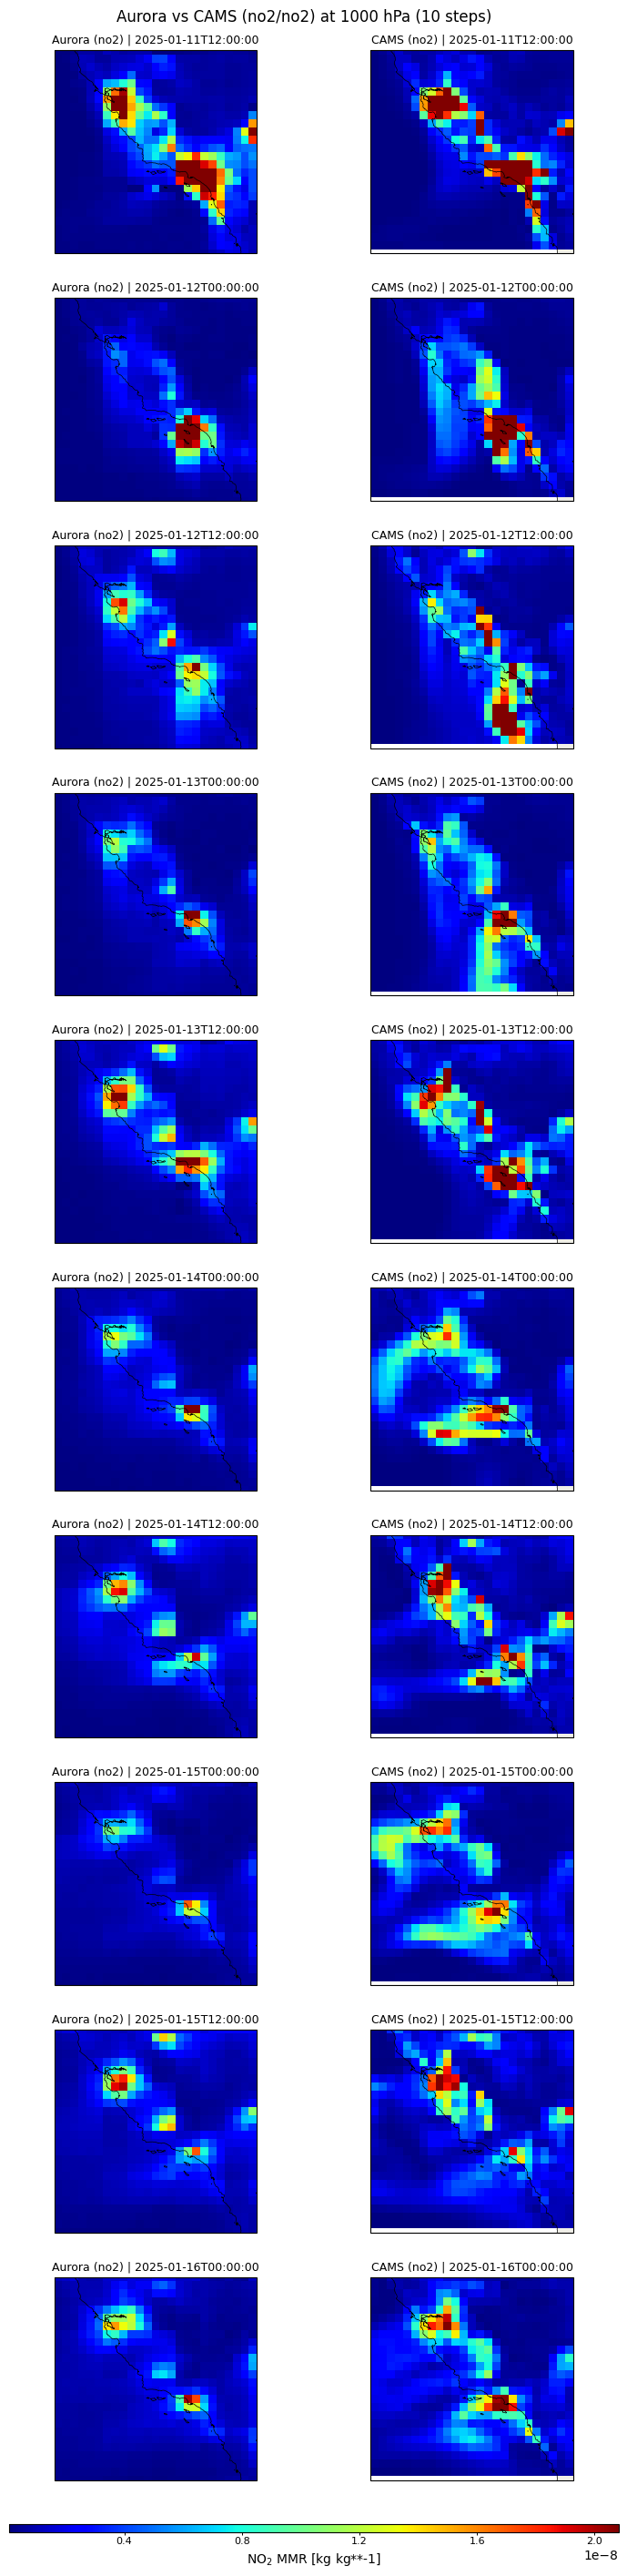

In [4]:
title_suffix = ""
if PRESSURE_LEVEL_HPA is not None:
    title_suffix = f" at {aurora_level if aurora_level is not None else PRESSURE_LEVEL_HPA} hPa"

_plot_map_pairs_by_time(
    aurora_var,
    cams_var,
    title_prefix=(
        f"Aurora vs CAMS ({AURORA_PLOT_LABEL}/{CAMS_PLOT_LABEL}){title_suffix} "
        f"({len(aurora_var.time)} steps)"
    ),
    vmin=vmin,
    vmax=vmax,
    cmap=COLORMAP,
    aurora_label=AURORA_PLOT_LABEL,
    cams_label=CAMS_PLOT_LABEL,
    colorbar_label=COLORBAR_LABEL,
    latitude_boundary=LATITUDE_BOUNDARY,
    longitude_boundary=LONGITUDE_BOUNDARY,
)


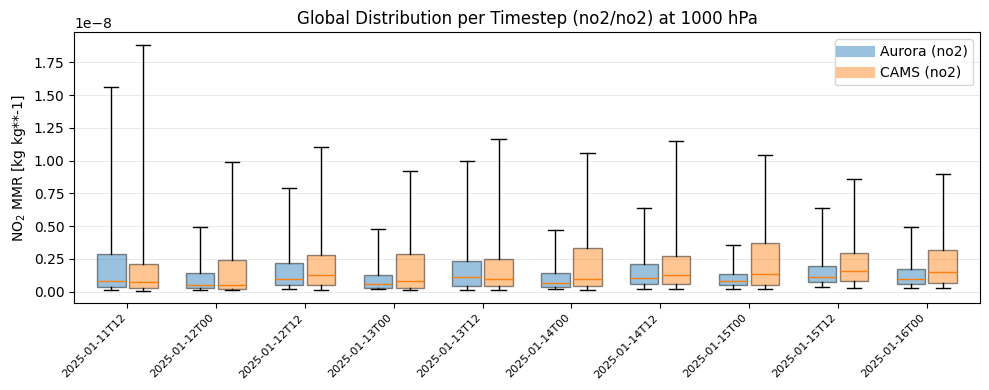

In [5]:
_plot_global_boxplots_by_time(
    aurora_var,
    cams_var,
    title_prefix=(
        f"Global Distribution per Timestep ({AURORA_PLOT_LABEL}/{CAMS_PLOT_LABEL}){title_suffix}"
    ),
    aurora_label=AURORA_PLOT_LABEL,
    cams_label=CAMS_PLOT_LABEL,
    colorbar_label=COLORBAR_LABEL,
)


In [6]:
if GENERATE_GIFS:
    gif_steps = min(int(GIF_NUM_STEPS), len(aurora_var.time))
    if gif_steps <= 0:
        raise ValueError("GIF_NUM_STEPS must be positive and there must be aligned timesteps.")

    aurora_gif_var = aurora_var.isel(time=slice(0, gif_steps))
    cams_gif_var = cams_var.isel(time=slice(0, gif_steps))

    title_suffix = ""
    if PRESSURE_LEVEL_HPA is not None:
        title_suffix = f" @ {aurora_level if aurora_level is not None else PRESSURE_LEVEL_HPA} hPa"

    aurora_gif_path = _save_map_gif_by_time(
        aurora_gif_var,
        AURORA_GIF_OUTPUT,
        title_prefix=f"Aurora ({AURORA_PLOT_LABEL}){title_suffix}",
        vmin=vmin,
        vmax=vmax,
        cmap=COLORMAP,
        series_label=AURORA_PLOT_LABEL,
        colorbar_label=COLORBAR_LABEL,
        frame_duration_ms=GIF_FRAME_DURATION_MS,
        latitude_boundary=LATITUDE_BOUNDARY,
        longitude_boundary=LONGITUDE_BOUNDARY,
    )

    cams_gif_path = _save_map_gif_by_time(
        cams_gif_var,
        CAMS_GIF_OUTPUT,
        title_prefix=f"CAMS ({CAMS_PLOT_LABEL}){title_suffix}",
        vmin=vmin,
        vmax=vmax,
        cmap=COLORMAP,
        series_label=CAMS_PLOT_LABEL,
        colorbar_label=COLORBAR_LABEL,
        frame_duration_ms=GIF_FRAME_DURATION_MS,
        latitude_boundary=LATITUDE_BOUNDARY,
        longitude_boundary=LONGITUDE_BOUNDARY,
    )

    print(f"Saved Aurora GIF ({gif_steps} frames): {aurora_gif_path}")
    print(f"Saved CAMS GIF ({gif_steps} frames): {cams_gif_path}")
else:
    print("Skipping GIF generation (GENERATE_GIFS=False).")


Saved Aurora GIF (10 frames): /mnt/data2/aurora/examples/aurora_no2_1000hpa_10plots.gif
Saved CAMS GIF (10 frames): /mnt/data2/aurora/examples/cams_no2_1000hpa_10plots.gif
